In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [ ]:
df = pd.read_csv('flow_logs_data.csv')

In [6]:
# Extract short VM name from full resource path  (e.g. "rg-.../flowdemo-app1" → "app1")
def short_name(val):
    if pd.isna(val) or str(val).strip() == "":
        return None
    return str(val).split("/")[-1].replace("flowdemo-", "")

df["src_node"] = df["SrcVm"].apply(short_name)
df["dst_node"] = df["DestVm"].apply(short_name)

# Also use raw IP as node label when VM name is missing
def node_label(vm_col, ip_col, row):
    name = short_name(row[vm_col])
    if name:
        return name
    ip = str(row[ip_col]).strip()
    return ip if ip not in ("", "nan") else "unknown"

df["src_label"] = df.apply(lambda r: node_label("SrcVm", "SrcIp", r), axis=1)
df["dst_label"] = df.apply(lambda r: node_label("DestVm", "DestIp", r), axis=1)

# ── 2. Filter: keep only flows where App1/2/3/4 is involved ──────────────────
APP_TARGETS = {"app1", "app2", "app3", "app4"}

mask = (
    df["src_node"].isin(APP_TARGETS) |
    df["dst_node"].isin(APP_TARGETS)
)
filtered = df[mask].copy()
print(f"Total rows after filter: {len(filtered)}")

# ── 3. Aggregate edges (src → dst, per FlowStatus) ───────────────────────────
edges = (
    filtered
    .groupby(["src_label", "dst_label", "FlowStatus"], dropna=False)
    .agg(flow_count=("FlowStatus", "count"))
    .reset_index()
)

Total rows after filter: 72


In [7]:
# ── 4. Build directed graph ───────────────────────────────────────────────────
G = nx.DiGraph()

for _, row in edges.iterrows():
    G.add_edge(
        row["src_label"],
        row["dst_label"],
        status=row["FlowStatus"],
        count=row["flow_count"],
    )

print(f"Nodes: {list(G.nodes())}")
print(f"Edges: {G.number_of_edges()}")

Nodes: ['app1', 'pgprimary', 'unknown', 'app2', 'app3', 'app4', 'applb']
Edges: 8


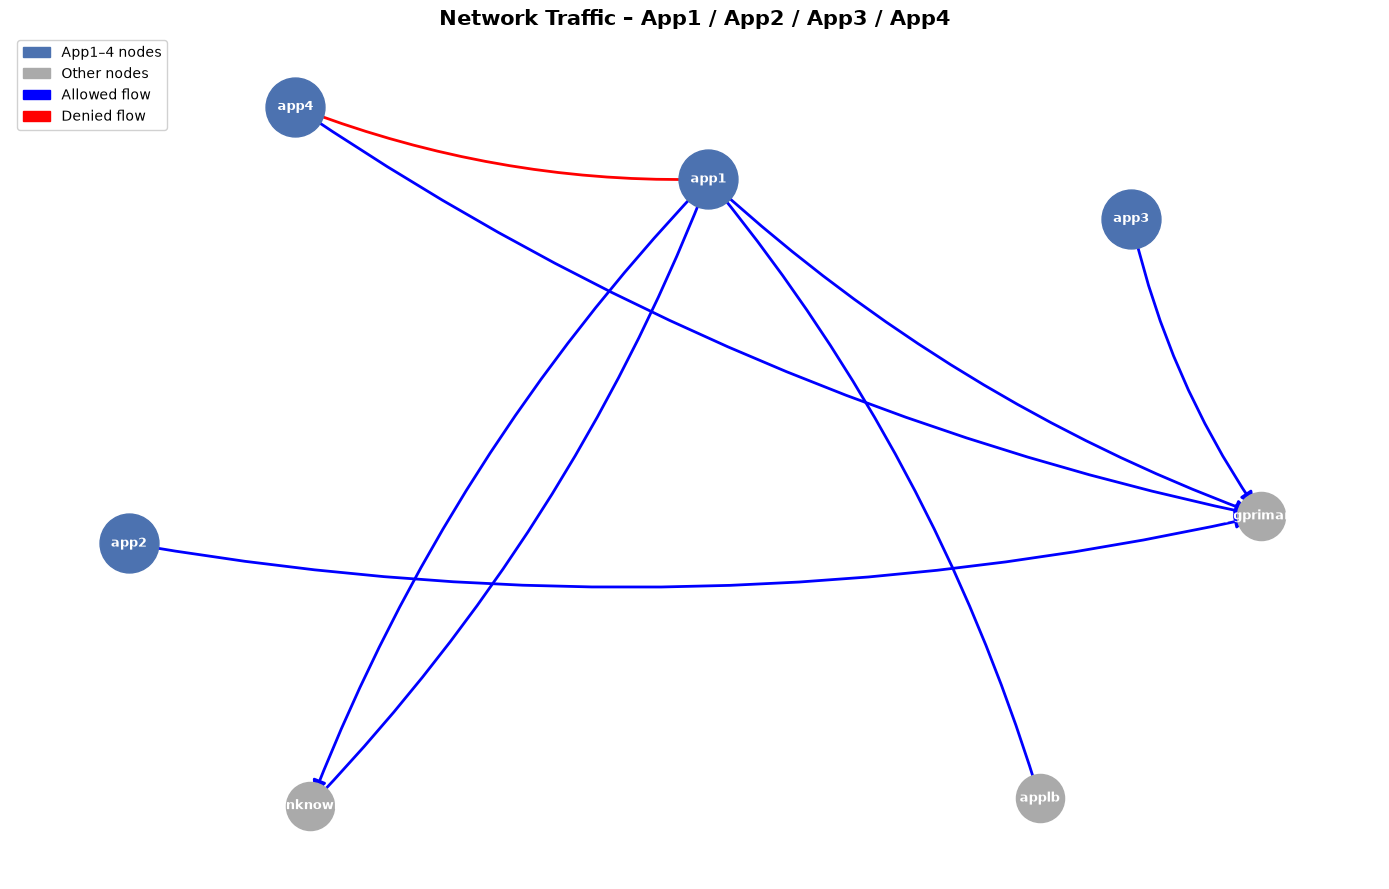

Graph saved to network_graph_app1234.png


In [8]:

# ── 5. Layout & draw ─────────────────────────────────────────────────────────
# Highlight the four App nodes
app_nodes   = [n for n in G.nodes() if n in APP_TARGETS]
other_nodes = [n for n in G.nodes() if n not in APP_TARGETS]

pos = nx.spring_layout(G, seed=42, k=2.5)

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_title("Network Traffic – App1 / App2 / App3 / App4", fontsize=15, fontweight="bold")

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=app_nodes,   node_color="#4C72B0",
                       node_size=1800, ax=ax, label="App nodes")
nx.draw_networkx_nodes(G, pos, nodelist=other_nodes, node_color="#AAAAAA",
                       node_size=1200, ax=ax, label="Other nodes")
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white",
                        font_weight="bold", ax=ax)

# Separate edges by status
allowed_edges = [(u, v) for u, v, d in G.edges(data=True) if d["status"] == "Allowed"]
denied_edges  = [(u, v) for u, v, d in G.edges(data=True) if d["status"] == "Denied"]

nx.draw_networkx_edges(G, pos, edgelist=allowed_edges,
                       edge_color="blue", arrows=True,
                       arrowsize=20, width=2.0,
                       connectionstyle="arc3,rad=0.1", ax=ax)

nx.draw_networkx_edges(G, pos, edgelist=denied_edges,
                       edge_color="red",  arrows=True,
                       arrowsize=20, width=2.0,
                       connectionstyle="arc3,rad=0.1", ax=ax)

# Legend
legend_handles = [
    mpatches.Patch(color="#4C72B0", label="App1–4 nodes"),
    mpatches.Patch(color="#AAAAAA", label="Other nodes"),
    mpatches.Patch(color="blue",    label="Allowed flow"),
    mpatches.Patch(color="red",     label="Denied flow"),
]
ax.legend(handles=legend_handles, loc="upper left", framealpha=0.9)

plt.axis("off")
plt.tight_layout()
plt.savefig("network_graph_app1234.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graph saved to network_graph_app1234.png")